## 1.Load Task in Benchmark Quickly

Tutorial one is to load a task/env conveniently by simply giving task name and desired target embodiment (default is Franka).

In [1]:
import os
# os.environ.setdefault("MUJOCO_GL", "egl")
import json
from PIL import Image
from dm_control import viewer
from VLABench.envs import load_env
from VLABench.robots import *
from VLABench.tasks import *
from VLABench.configs import name2config
from VLABench.utils.utils import find_key_by_value

/home/jadelynn/miniconda3/envs/vlabench/lib/python3.10/site-packages/dash/_jupyter.py:30: DeprecationWarning: The `ipykernel.comm.Comm` class has been deprecated. Please use the `comm` module instead.For creating comms, use the function `from comm import create_comm`.
  _dash_comm = Comm(target_name="dash")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Set the embodiment and task 

In [2]:
task = "select_fruit"
robot = "franka"

If run this tutorial on server instead of PC, run in headless mode.

In [3]:
os.environ["MUJOCO_GL"] = "egl"

###  1.1Load task and build environment

Each time you load the single env, each instance varies in a large range.

In [3]:
env = load_env(task, robot=robot, time_limit=1000)
env.reset()

TimeStep(step_type=<StepType.FIRST: 0>, reward=None, discount=None, observation={})

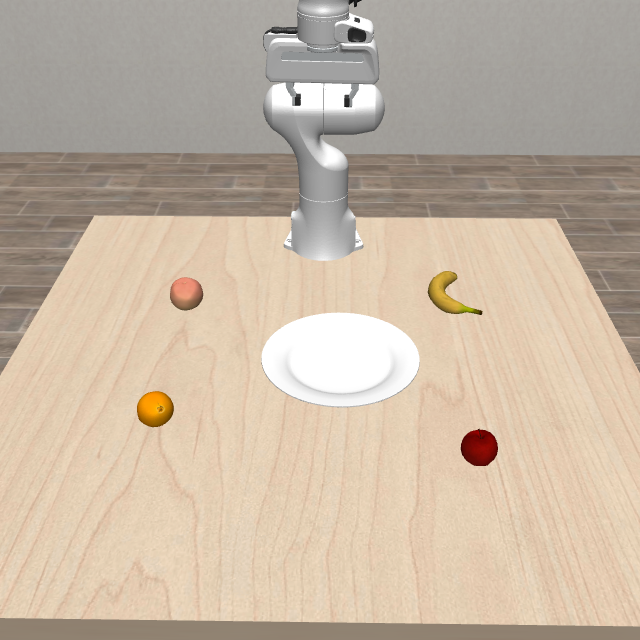

In [4]:
image = env.render(camera_id=2, width=640, height=640)
Image.fromarray(image)

In [5]:
obs=env.get_observation()
obs

{'q_state': array([ 2.95987780e-06, -1.04758420e+00,  3.17353756e-03, -2.63995536e+00,
        -4.40926257e-03,  1.53563645e+00, -2.31999842e+00]),
 'q_velocity': array([ 3.00549191e-06, -2.04173632e-03,  9.75554478e-04, -2.38824520e-02,
        -1.29761598e-03, -4.19126729e-03,  2.02324655e-06]),
 'q_acceleration': array([ 1.27930789e-03,  6.75749215e-02, -1.12792787e-02,  3.56739839e-01,
         1.54173039e-02,  1.85087997e-02, -3.55609045e-04]),
 'rgb': array([[[[ 90,  90,  89],
          [ 90,  89,  88],
          [ 76,  76,  76],
          ...,
          [142, 140, 136],
          [142, 139, 135],
          [142, 139, 135]],
 
         [[134, 132, 128],
          [133, 130, 127],
          [132, 129, 125],
          ...,
          [141, 139, 134],
          [141, 138, 133],
          [142, 139, 135]],
 
         [[132, 130, 126],
          [132, 129, 126],
          [132, 129, 125],
          ...,
          [141, 138, 134],
          [142, 140, 135],
          [142, 140, 136]],
 

### 1.2Run in interactive viewer

If headless (EGL), render to video inline.
If there is a display (GLFW), launch viewer.

In [ ]:
# With display
viewer.launch(env)

In [ ]:
# Without display
from VLABench.envs import load_env
import mediapy as media

W, H, T = 640, 640, 300  # ~10s at 30 FPS
frames = []

for _ in range(T):
    action = env.action_spec().generate_value()   # replace with your policy
    ts = env.step(action)
    frame = env.render(camera_id=2, width=W, height=H)  # (H,W,3) uint8
    frames.append(frame)

media.show_video(frames, fps=10)

This browser does not support the video tag.


## 2.Overview of Primitive Tasks

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap

def plot_images(images, instructions, titles, max_columns=5, max_text_width=30):
    assert len(images) == len(instructions) == len(titles), f"images ({len(images)}) should have the same length as instructions ({len(instructions)}) and titles ({len(titles)})"
    num_images = len(images)
    num_rows = (num_images + max_columns - 1) // max_columns
    fig, axes = plt.subplots(num_rows, max_columns, figsize=(max_columns * 3, num_rows * 3))
    axes = axes.flatten()
    for i, (image, instruction, title) in enumerate(zip(images, instructions, titles)):
        if np.max(image) <= 1:
            image = (image * 255).astype(np.uint8)
        ax = axes[i]
        ax.imshow(image)
        ax.axis('off')
        ax.set_title(title, fontsize=14)
        wrapped_instruction = textwrap.fill(instruction, width=max_text_width)
        ax.text(0.5, -0.1, wrapped_instruction, ha='center', va='top', transform=ax.transAxes, fontsize=12)
        
    for i in range(num_images, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [13]:
def load_env_and_render(task, robot, **kwargs):
    env = load_env(task, robot=robot, **kwargs)
    env.reset()

    image = env.render(camera_id=2, width=480, height=480)
    instruction = env.task.get_instruction()
    return image, instruction

### 2.1 Basic Scene: Mesh&Texture 

Default Setting: no additional domain randomization, no texture and scene augmenation

In [14]:
tasks_to_load = ["select_toy", "select_fruit", "select_chemistry_tube", "select_mahjong", "select_poker", "add_condiment", "insert_flower", "select_book", "select_billiards", "select_drink", "select_ingredient", "select_painting","put_box_on_painting"]
images, instructions, loaded_tasks = [], [], []
for task in tasks_to_load:
    try:
        image, instruction = load_env_and_render(task, robot, reset_wait_step=0)
        images.append(image)
        instructions.append(instruction)
        loaded_tasks.append(task)
    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f"Failed to load task {task}: {e}")

Traceback (most recent call last):
  File "/home/jadelynn/miniconda3/envs/vlabench/lib/python3.10/site-packages/dm_control/mjcf/physics.py", line 461, in from_mjcf_model
    return cls.from_xml_string(xml_string=xml_string, assets=assets)
  File "/home/jadelynn/miniconda3/envs/vlabench/lib/python3.10/site-packages/dm_control/mujoco/engine.py", line 443, in from_xml_string
    model = wrapper.MjModel.from_xml_string(xml_string, assets=assets)
  File "/home/jadelynn/miniconda3/envs/vlabench/lib/python3.10/site-packages/dm_control/mujoco/wrapper/core.py", line 294, in from_xml_string
    model_ptr = _get_model_ptr_from_xml(xml_string=xml_string, assets=assets)
  File "/home/jadelynn/miniconda3/envs/vlabench/lib/python3.10/site-packages/dm_control/mujoco/wrapper/core.py", line 179, in _get_model_ptr_from_xml
    ptr = mujoco.MjModel.from_xml_string(xml_string, assets or {})
ValueError: Error: mesh volume is too small: billiards_table/billiards_table_8 . Try setting inertia to shell
Element

Failed to load task select_billiards: Compile error raised by Mujoco; run again with --pymjcf_debug for additional debug information.
Error: mesh volume is too small: billiards_table/billiards_table_8 . Try setting inertia to shell
Element name 'billiards_table/billiards_table_8', id 153, line 375
<mesh name="billiards_table/billiards_table_8" class="billiards_table/" file="billiards_table_8-31b0ea6112ed8ca731cf05f6e1bca0b559315f1d.obj" scale="0.29999999999999999 0.29999999999999999 0.29999999999999999"/>
Failed to load task put_box_on_painting: 'NoneType' object has no attribute 'lower'


Traceback (most recent call last):
  File "/tmp/ipykernel_10699/1216403800.py", line 5, in <module>
    image, instruction = load_env_and_render(task, robot, reset_wait_step=0)
  File "/tmp/ipykernel_10699/396753600.py", line 2, in load_env_and_render
    env = load_env(task, robot=robot, **kwargs)
  File "/home/jadelynn/VLABench/VLABench/envs/__init__.py", line 52, in load_env
    task = register.load_task(task)(task, robot, episode_config=episode_config, random_init=random_init, **kwargs)
  File "/home/jadelynn/VLABench/VLABench/tasks/hierarchical_tasks/primitive/select_painting_series.py", line 197, in __init__
    super().__init__(task_name, robot=robot, **kwargs)
  File "/home/jadelynn/VLABench/VLABench/tasks/hierarchical_tasks/primitive/select_painting_series.py", line 182, in __init__
    super().__init__(task_name, robot=robot, **kwargs)
  File "/home/jadelynn/VLABench/VLABench/tasks/dm_task.py", line 76, in __init__
    self.build_from_config(eval, deterministic_config=episode

/tmp/ipykernel_230505/3772757699.py:24: UserWarning: Glyph 23614 (\N{CJK UNIFIED IDEOGRAPH-5C3E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_230505/3772757699.py:24: UserWarning: Glyph 24030 (\N{CJK UNIFIED IDEOGRAPH-5DDE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_230505/3772757699.py:24: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_230505/3772757699.py:24: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_230505/3772757699.py:24: UserWarning: Glyph 35211 (\N{CJK UNIFIED IDEOGRAPH-898B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_230505/3772757699.py:24: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/jadelynn/miniconda3/envs/vlabench/lib/python3.10/site-packages/IPython/core/

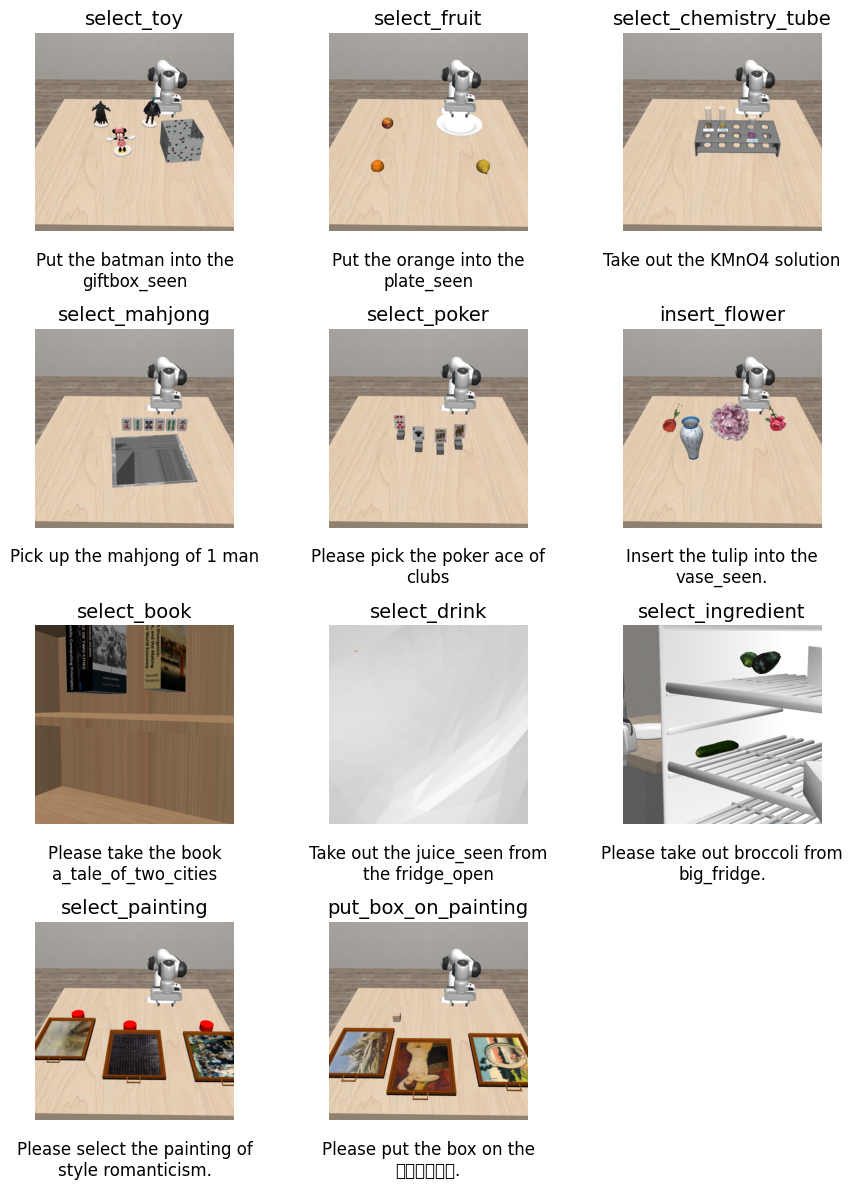

In [25]:
plot_images(images, instructions, titles=loaded_tasks, max_columns=3)

### 2.2 Common Sense & World Knowledge

The base environment for Common Sense & World Knowledge type tasks quering LLM to generate task instructions by default. We also recommend to generate the instructions in batch later.

In [27]:
tasks_to_load = ["hammer_loose_nail"]

### 2.3 Spatial Understanding

The base environment for spatial understanding generate the relative spatial relationships between target entity and other entities by task-specific rules.

In [ ]:
tasks_to_load = ["select_toy_spatial", "select_fruit_spatial", "select_chemistry_tube_spatial", "select_mahjong_spatial", "select_poker_spatial", "add_condiment_spatial", "insert_flower_spatial", "select_book_spatial", "select_billiards_spatial", "select_drink_spatial", "select_ingredient_spatial"]
# "", "select_poker", "add_condiment", "insert_flower", "select_book", "select_billiards", "select_drink", "select_ingredient", "select_painting","put_box_on_painting"
images, instructions, loaded_tasks = [], [], []
robot="franka"
for task in tasks_to_load:
    try:
        image, instruction = load_env_and_render(task, robot, reset_wait_step=0)
        images.append(image)
        instructions.append(instruction)
        loaded_tasks.append(task)
    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f"Failed to load task {task}: {e}")
plot_images(images, instructions, titles=loaded_tasks, max_columns=3)

### 2.4 Semantic Understanding

In [ ]:
tasks_to_load = ["select_toy_semantic", "select_fruit_semantic"]
for task in tasks_to_load:
    try:
        image, instruction = load_env_and_render(task, robot, reset_wait_step=0)
        images.append(image)
        instructions.append(instruction)
    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f"Failed to load task {task}: {e}")


In [ ]:
instructions

## 3.Overview of Composite Tasks

### 3.1Cluster series tasks

In [ ]:
tasks_to_load = ["cluster_book", "cluster_billiards", "cluster_toy", "cluster_dessert", "cluster_drink", "cluster_ingredients"]
images, instructions = [], []
for task in tasks_to_load:
    image, instruction = load_env_and_render(task, robot, reset_wait_step=0)
    images.append(image)
    instructions.append(instruction)
plot_images(images, instructions, titles=tasks_to_load, max_columns=3)

### 3.2 Other Composite Tasks 

In [ ]:
tasks_to_load = ["texas_holdem", "texas_holdem_explore", "set_dining_table", "set_dining_left_hand", "set_dining_chopstick", "find_unseen_object", "cool_drink", "take_out_cool_drink", "book_rearrange", "heat_food", "rearrange_tube", "take_chemistry_experiment", "get_coffee", "get_coffee_with_sugar", "get_coffee_with_milk", "hammer_nail_and_hang_picture", "make_juice", "cook_dishes", "store_food", "play_mahjong", "complex_seesaw_use", "play_math_game", "set_study_table"]
images, instructions = [], []
for task in tasks_to_load:
    image, instruction = load_env_and_render(task, robot, reset_wait_step=0)
    images.append(image)
    instructions.append(instruction)
plot_images(images, instructions, titles=tasks_to_load, max_columns=3)